
# Proyecto I - Parte 5  
# Análisis Exploratorio de Datos (EDA)

## Objetivo
Aplicar técnicas de análisis exploratorio de datos utilizando visualizaciones avanzadas para identificar patrones y relaciones relevantes dentro del dataset de ventas retail.



### Instrucciones

1. Continuar desde la Parte IV
    - Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.
2. Exploración de Datos Avanzada
    - Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.
    - Crea subplots para comparar diferentes variables clave.
    - Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.
3. Generar un Tag en GitHub y Realizar una Presentación
    - Generar un Tag en GitHub: Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub, genera un Pull Request (PR) para revisión y finalmente crea un tag para esta versión del proyecto.
    - Realizar una Presentación: Prepara una presentación en slides que resuma tu análisis y visualizaciones. La presentación debe incluir:
        - Introducción y objetivos del proyecto.
        - Descripción del conjunto de datos.
        - Principales análisis y hallazgos.
        - Visualizaciones clave con explicación.
        - Conclusiones y recomendaciones.

    Utiliza herramientas como PowerPoint, Google Slides o cualquier otra aplicación de presentación.


# 1. Importación de librerías y carga de datos

In [1]:

# Carga de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set(style='whitegrid')

# Carga del dataset
# Opción 1: si el archivo está en una carpeta data
try:
    df = pd.read_csv('../data/retail_sales_dataset.csv')

# Opción 2: si el archivo está en la misma carpeta del notebook
except FileNotFoundError:
    df = pd.read_csv('retail_sales_dataset.csv')

df.head(10)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


# 2. Exploración inicial del dataset

In [2]:

# Se muestran filas y columnas
print("Filas y columnas del dataset")
print("="*80)
print(df.shape)
print("-"*80)

# Se muestran las primeras 10 filas
print("Primeras 10 filas")
print("="*80)
display(df.head(10))
print("-"*80)

# Se muestran las últimas 5 filas
print("Últimas 5 filas")
print("="*80)
display(df.tail(5))
print("-"*80)

# Información general del DataFrame
print("Información general del DataFrame")
print("="*80)
df.info()
print("-"*80)

# Estadísticas descriptivas
print("Estadísticas descriptivas de columnas numéricas")
display(df.describe())

print("Estadísticas descriptivas de columnas categóricas")
display(df.describe(include='object'))


Filas y columnas del dataset
(1000, 9)
--------------------------------------------------------------------------------
Primeras 10 filas


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


--------------------------------------------------------------------------------
Últimas 5 filas


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


--------------------------------------------------------------------------------
Información general del DataFrame
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
--------------------------------------------------------------------------------
Estadísticas descriptivas de columnas numéricas


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Estadísticas descriptivas de columnas categóricas


<positron-console-cell-2>:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST001,Female,Clothing
freq,11,1,510,351



# 3. Mapa de calor de correlación

Para este análisis se seleccionan variables numéricas del dataset:
- edad,
- precio por unidad,
- cantidad comprada,
- y monto total.

El objetivo es observar si existe relación entre el precio, la cantidad y el gasto final de los clientes.


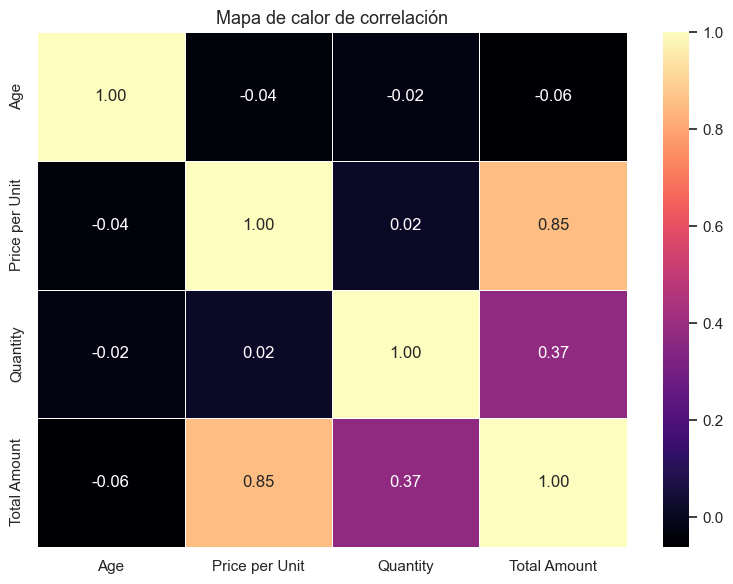

In [3]:

variables = ['Age', 'Price per Unit', 'Quantity', 'Total Amount']

plt.figure(figsize=(8,6))

sns.heatmap(
    df[variables].corr(),
    annot=True,
    cmap='magma',
    linewidths=0.5,
    fmt='.2f'
)

plt.title('Mapa de calor de correlación', fontsize=13)
plt.tight_layout()
plt.show()



# 4. Visualizaciones avanzadas con subplots

Se utilizan diferentes combinaciones de variables para comparar patrones de compra desde distintos puntos de vista.  
Los gráficos fueron ajustados para que las etiquetas, títulos y leyendas se vean con mayor claridad.


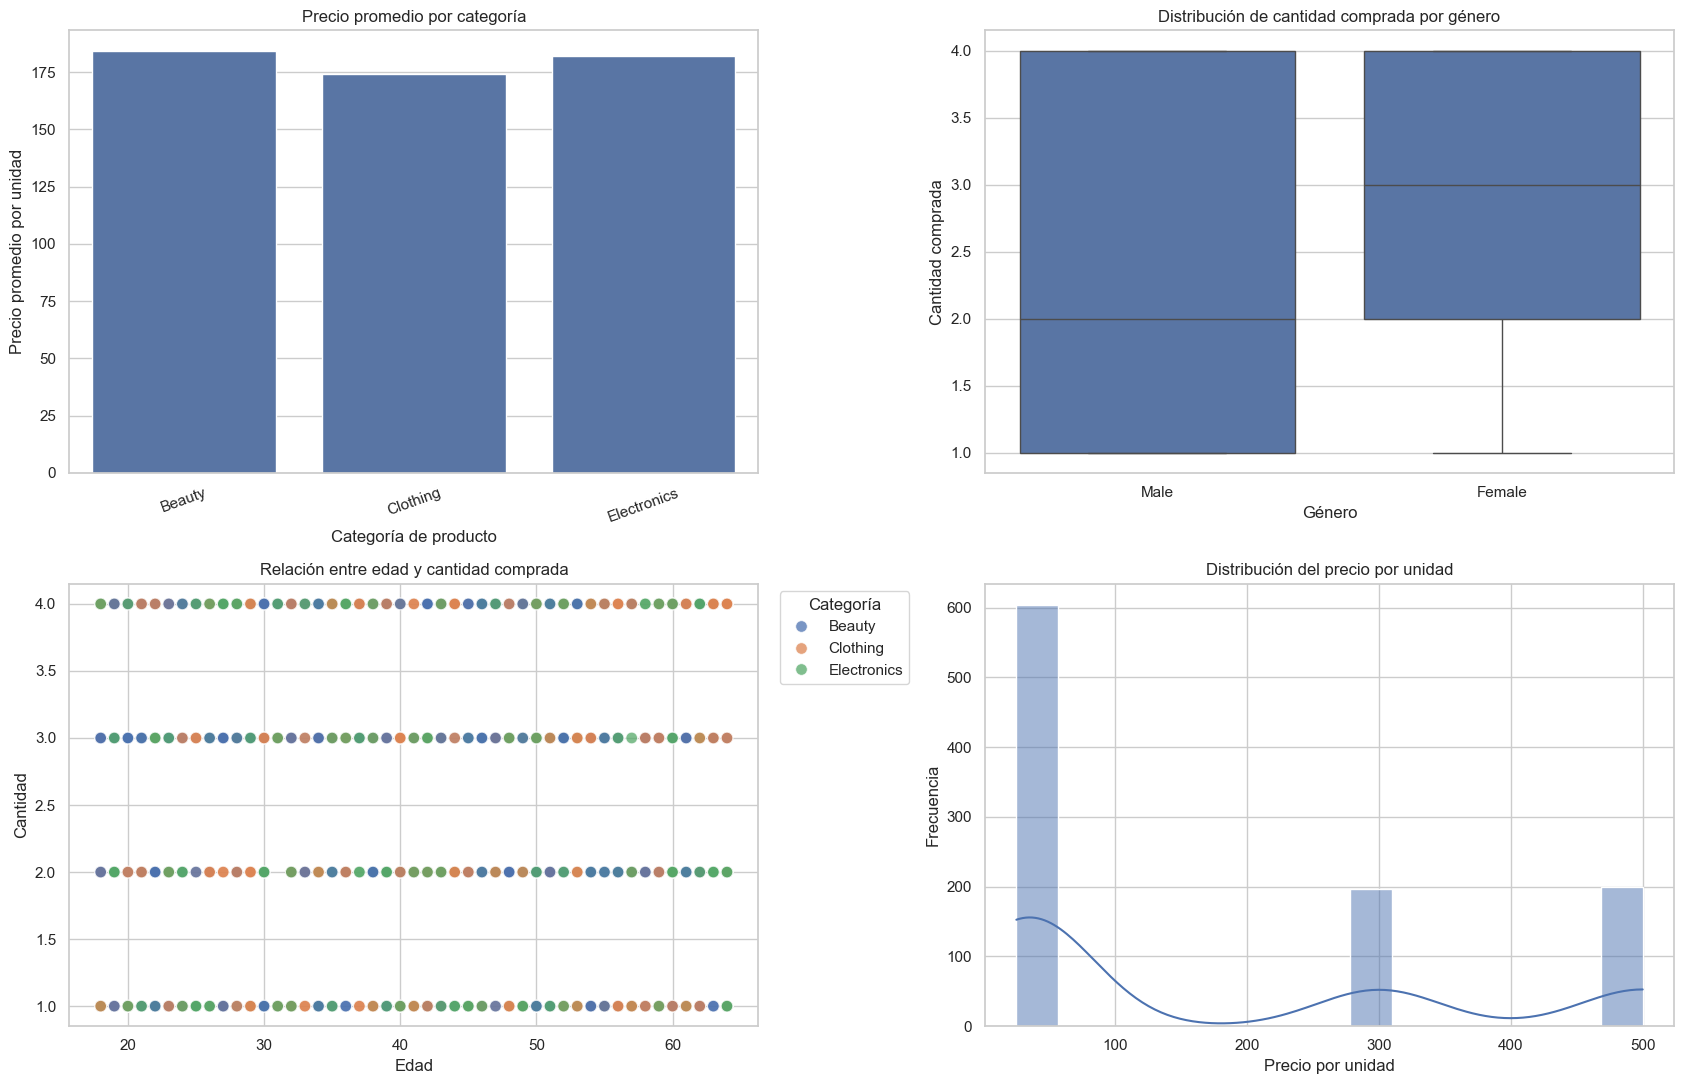

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# 1. Precio promedio por categoría
sns.barplot(
    data=df,
    x='Product Category',
    y='Price per Unit',
    estimator=np.mean,
    errorbar=None,
    ax=axes[0,0]
)
axes[0,0].set_title('Precio promedio por categoría', fontsize=12)
axes[0,0].set_xlabel('Categoría de producto')
axes[0,0].set_ylabel('Precio promedio por unidad')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. Cantidad comprada por género
sns.boxplot(
    data=df,
    x='Gender',
    y='Quantity',
    ax=axes[0,1]
)
axes[0,1].set_title('Distribución de cantidad comprada por género', fontsize=12)
axes[0,1].set_xlabel('Género')
axes[0,1].set_ylabel('Cantidad comprada')

# 3. Edad vs cantidad, separado por categoría
sns.scatterplot(
    data=df,
    x='Age',
    y='Quantity',
    hue='Product Category',
    alpha=0.75,
    s=70,
    ax=axes[1,0]
)
axes[1,0].set_title('Relación entre edad y cantidad comprada', fontsize=12)
axes[1,0].set_xlabel('Edad')
axes[1,0].set_ylabel('Cantidad')
axes[1,0].legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left')

# 4. Distribución del precio unitario
sns.histplot(
    data=df,
    x='Price per Unit',
    bins=15,
    kde=True,
    ax=axes[1,1]
)
axes[1,1].set_title('Distribución del precio por unidad', fontsize=12)
axes[1,1].set_xlabel('Precio por unidad')
axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()



# 5. Visualización interactiva con Plotly

Para cumplir con el uso de Plotly, se genera un gráfico interactivo que compara el monto total vendido por categoría y género.  
Este gráfico permite visualizar mejor las diferencias entre grupos, ya que al pasar el cursor sobre las barras se muestran los valores exactos.


In [5]:

ventas_categoria_genero = (
    df.groupby(['Product Category', 'Gender'], as_index=False)['Total Amount']
      .sum()
      .sort_values('Total Amount', ascending=False)
)

fig = px.bar(
    ventas_categoria_genero,
    x='Product Category',
    y='Total Amount',
    color='Gender',
    barmode='group',
    text='Total Amount',
    title='Ventas totales por categoría y género'
)

fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')

fig.update_layout(
    xaxis_title='Categoría de producto',
    yaxis_title='Monto total vendido',
    legend_title='Género',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()


# 6. Cuadrículas, leyendas, anotaciones y flechas

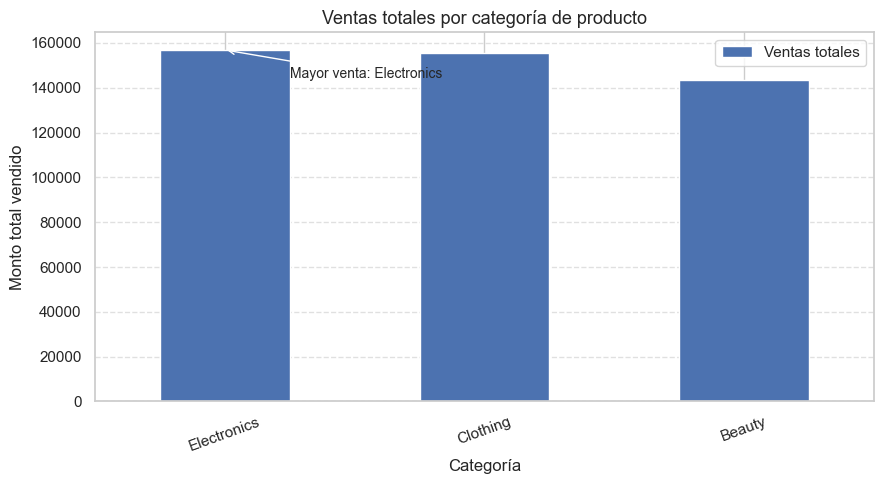

In [7]:

ventas_categoria = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

categoria_mayor = ventas_categoria.idxmax()
valor_mayor = ventas_categoria.max()
posicion_mayor = list(ventas_categoria.index).index(categoria_mayor)

plt.figure(figsize=(9,5))

ax = ventas_categoria.plot(kind='bar')

plt.grid(True, linestyle='--', alpha=0.6, axis='y')

plt.title('Ventas totales por categoría de producto', fontsize=13)
plt.xlabel('Categoría')
plt.ylabel('Monto total vendido')
plt.xticks(rotation=20)

plt.legend(['Ventas totales'])

plt.annotate(
    f'Mayor venta: {categoria_mayor}',
    xy=(posicion_mayor, valor_mayor),
    xytext=(posicion_mayor + 0.25, valor_mayor * 0.92),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

plt.tight_layout()
plt.show()



# 7. Interpretación de resultados

## Hallazgos

- El mapa de calor permite observar que el monto total está asociado principalmente con la cantidad comprada y el precio por unidad.
- El precio promedio cambia según la categoría de producto, lo que indica diferencias relevantes entre tipos de artículos.
- La cantidad comprada por género se mantiene relativamente concentrada, sin diferencias extremas.
- La relación entre edad y cantidad comprada no muestra un patrón lineal fuerte.
- El gráfico interactivo de Plotly facilita comparar las ventas por categoría y género de forma más clara.
- La visualización con anotación permite identificar rápidamente la categoría con mayor monto total vendido.

Las visualizaciones ayudan a comprender el comportamiento general de las compras y facilitan la detección de patrones dentro del dataset.



# 8. Conclusión

El análisis exploratorio permitió identificar patrones relevantes dentro del dataset retail mediante visualizaciones avanzadas.

El uso combinado de Seaborn, Matplotlib y Plotly permitió representar relaciones entre variables numéricas y categóricas, mejorar la lectura de los gráficos e incorporar elementos visuales como leyendas, cuadrículas, anotaciones y flechas.

Este proceso es una etapa importante dentro de Data Science y Machine Learning, ya que permite comprender mejor los datos antes de aplicar modelos predictivos.
